<a href="https://colab.research.google.com/github/Zarak00/Projects/blob/main/Acute%20promyelocytic%20leukemia/APL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm


### Clone the GitHub repository

In [ ]:
!git clone https://github.com/sidhomj/DeepAPL.git

Cloning into 'DeepAPL'...
remote: Enumerating objects: 20609, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 20609 (delta 52), reused 66 (delta 37), pack-reused 20522 (from 1)
Receiving objects: 100% (20609/20609), 476.68 MiB | 23.24 MiB/s, done.
Resolving deltas: 100% (560/560), done.
Updating files: 100% (26123/26123), done.


### Extract images using `glob`

In [ ]:
# image_folder_path = '/content/DeepAPL/Data/Clinical_Case/cc/Signed slides/*/*.jpg'
image_folder_path = '/content/DeepAPL/Data/All/**/*.jpg'

# Use glob to get all .jpg images in subdirectories
image_paths = glob.glob(image_folder_path, recursive=True)

# Check the first few images to ensure it's working
print("First 5 image paths:", image_paths[:5])

First 5 image paths: ['/content/DeepAPL/Data/All/Patient_05/Signed slides/Blast, no lineage spec/BL_9357385.jpg', '/content/DeepAPL/Data/All/Patient_05/Signed slides/Blast, no lineage spec/BL_9357486.jpg', '/content/DeepAPL/Data/All/Patient_05/Signed slides/Blast, no lineage spec/BL_9357452.jpg', '/content/DeepAPL/Data/All/Patient_05/Signed slides/Blast, no lineage spec/BL_9357528.jpg', '/content/DeepAPL/Data/All/Patient_05/Signed slides/Blast, no lineage spec/BL_9357384.jpg']


In [ ]:
# catalogue of image paths
df = pd.DataFrame(image_paths, columns=['img_path'])

# which actually load
df['valid_path'] = True
for i in tqdm(df.index):
    try:
        # try to load
        _ = plt.imread(df.at[i, 'img_path'])
    except OSError as e:
        print(e)
        df.at[i, 'valid_path'] = False

df['cell_type'] = df['img_path'].str.extract(r'slides/([^/]+)/')
df['patient'] = df['img_path'].str.extract(r'Data/All/([^/]+)/')
df['cell_int'] = np.nan
df.loc[~df['cell_type'].isna(), 'cell_int'] = 0
df.loc[df['cell_type'].str.contains(r'^Blast', na=False), 'cell_int'] = 2
df.loc[df['cell_type'].str.contains(r'^Lymphocyte', na=False), 'cell_int'] = 1
pf = pd.read_csv('./DeepAPL/Data/master.csv', sep=',')
df = pd.merge(df, pf[['Patient_ID', 'Diagnosis']], how='left', left_on='patient', right_on='Patient_ID').drop(columns=['Patient_ID'])


 15%|█▌        | 3983/25724 [00:07<00:38, 568.94it/s]

image file is truncated (13 bytes not processed)


 19%|█▊        | 4768/25724 [00:08<00:31, 672.22it/s]

image file is truncated (5 bytes not processed)


 31%|███       | 7937/25724 [00:13<00:27, 648.40it/s]

...

 65%|██████▍   | 16649/25724 [00:32<00:16, 562.96it/s]

image file is truncated (11 bytes not processed)


 89%|████████▊ | 22797/25724 [00:48<00:04, 655.77it/s]

image file is truncated (10 bytes not processed)


100%|██████████| 25724/25724 [00:53<00:00, 482.02it/s]


### Load and split the dataset into training and validation sets

In [ ]:
df['cell_type'].value_counts()

,count
cell_type,
Lymphocyte,3435
"Blast, no lineage spec",3310
Smudge cells,2931
Segmented neutrophils,2092
Monocyte,1319
Promyelocyte,688
Erythroblast,521
"Lymphocyte, variant",471
Myelocyte,181


In [ ]:
# which files to start with
idx = ~df['cell_int'].isna() & df['valid_path']

# Split the image paths into training and validation sets
train_idx, val_idx = train_test_split(df.loc[idx, 'img_path'].index, test_size=0.2, random_state=42)

# Check the split sizes
print(f"Training set size: {len(train_idx)}")
print(f"Validation set size: {len(val_idx)}")

Training set size: 12500
Validation set size: 3125


### Visualize a few sample images with labels

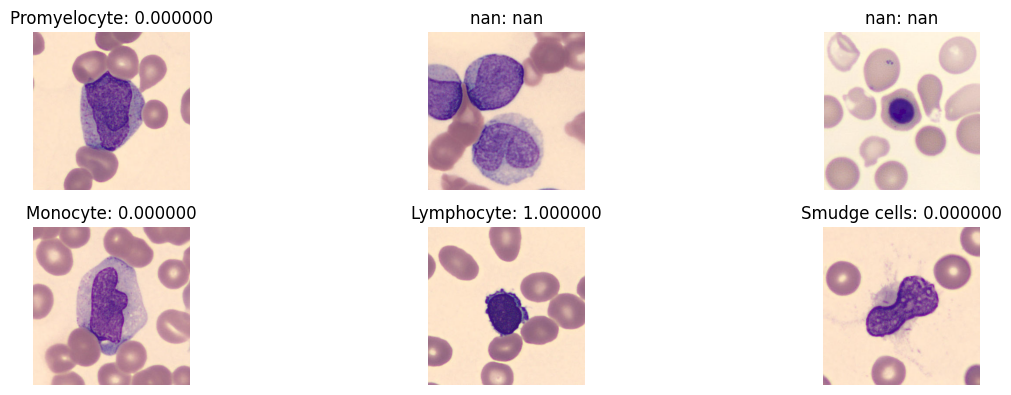

In [ ]:
# Visualize the first 5 images in the training set with correct labels
plt.figure(figsize=(12, 6))
for i, (idx, df_record) in enumerate(df.sample(6).iterrows()):
    ax = plt.subplot(3, 3, i + 1)
    img = plt.imread(df_record['img_path'])
    ax.imshow(img)
    ax.set_title('%s: %f' % (df_record['cell_type'], df_record['cell_int']))
    ax.axis('off')
plt.tight_layout()
plt.show()

### Apply data augmentation to the training dataset

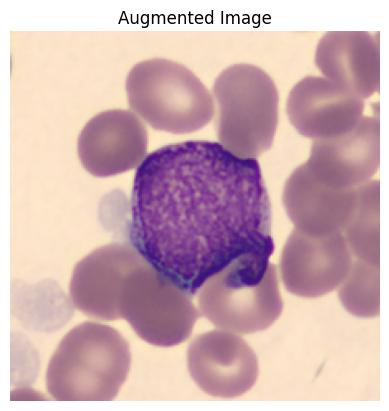

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Flip images randomly
    tf.keras.layers.RandomRotation(.75)  # Random rotation between -20% and +20%
])
data_augmentation.trainable = False

# Function to load and augment the image
def load_and_augment_image(img_path):
    # Load the image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)  # Decode JPEG image
    img = tf.image.resize(img, [224, 224])  # Resize to 224x224
    img = data_augmentation(img)  # Apply augmentation
    return img

# Load and augment the first image
augmented_image = load_and_augment_image(df.loc[0, 'img_path'])

# Display the augmented image
plt.imshow(augmented_image.numpy().astype("uint8"))
plt.title("Augmented Image")
plt.axis('off')
plt.show()


### Preprocess the data and create TensorFlow Dataset

In [ ]:
# Define image preprocessing function for training
def preprocess_train_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = data_augmentation(img)  # Apply data augmentation
    img = tf.keras.applications.resnet50.preprocess_input(img)  # Preprocess for ResNet50
    return img

# Define image preprocessing function for validation
def preprocess_val_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.keras.applications.resnet50.preprocess_input(img)  # Preprocess for ResNet50
    return img

# Create TensorFlow datasets for training and validation
train_ds = tf.data.Dataset.from_tensor_slices((df.loc[train_idx, 'img_path'].values, df.loc[train_idx, 'cell_int'].values))
train_ds = train_ds.map(lambda X, y: (preprocess_train_image(X), y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000, reshuffle_each_iteration=True).batch(32, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((df.loc[val_idx, 'img_path'].values, df.loc[val_idx, 'cell_int'].values))
val_ds = val_ds.map(lambda X, y: (preprocess_val_image(X), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

# Check the shape of one batch to ensure the data is ready
for images, y in train_ds.take(1):
    print("Batch shape:", images.shape)

Batch shape: (32, 224, 224, 3)


### pre-trained ResNet50 base model and add MLP classification head

In [ ]:
# Load pre-trained ResNet50 model, Imagenet
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',  # Use ImageNet weights
    include_top=False,  # Exclude the top classification layer
    input_shape=(224, 224, 3)  # Input size should match image shape
)

# Freeze the base model layers to prevent training on pre-trained weights
base_model.trainable = False

# Build the classification head (MLP)
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # Do not train the base model
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Global average pooling layer
x = tf.keras.layers.BatchNormalization()(x)  # Batch normalization for stability
x = tf.keras.layers.Dense(128, activation='relu')(x)  # Fully connected layer with ReLU
x = tf.keras.layers.BatchNormalization()(x)  # Batch normalization again
x = tf.keras.layers.Dropout(0.5)(x)  # Dropout for regularization
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)  # Output layer with softmax

# Create the final model
model = tf.keras.Model(inputs, outputs)

# Show model summary to verify architecture
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,859,075 (91.02 MB)

 Trainable params: 267,011 (1.02 MB)

 Non-trainable params: 23,592,064 (90.00 MB)

### Compile the model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Adam optimizer with learning rate
    loss="sparse_categorical_crossentropy",  # Loss function for multi-class classification
    metrics=["accuracy"]  # Metric to evaluate the model's performance
)

# Check the compiled model summary
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,859,075 (91.02 MB)

 Trainable params: 267,011 (1.02 MB)

 Non-trainable params: 23,592,064 (90.00 MB)

### Train the model

In [ ]:
## ALEX
# callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True, mode='min'),
    # tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1
]

# Train the model
history = model.fit(
    train_ds,  # Training dataset
    validation_data=val_ds,  # Validation dataset
    callbacks=callbacks,
    class_weight=dict(zip(np.arange(model.output_shape[-1]), np.ones(model.output_shape[-1]))),
    epochs=10,  # Set the number of epochs
)


Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 170s 410ms/step - accuracy: 0.7725 - loss: 0.5983 - val_accuracy: 0.8410 - val_loss: 0.4138
Epoch 2/10
 68/390 ━━━━━━━━━━━━━━━━━━━━ 1:57 366ms/step - accuracy: 0.8054 - loss: 0.4967

KeyboardInterrupt: 